# 16장 실습 — 평가 규약과 통계적 검정력

이 책은 열다섯 장 동안 「A 가 B 보다 낫다」를 여러 번 적었다. 이 노트북은 그 주장들을 **다시 검정**한다. 새로 돌리는 것은 거의 없다. 각 장이 남긴 판별 로그(`report/ch01~15_log.csv`)를 읽는다.

질문은 둘이다.

- **판 단위로 세면 유의하고, 시드 단위로 세면 유의한가.** 같은 정책을 수백 판 돌려도 정책은 하나다. 학습 시드를 바꾸면 정책이 바뀐다. 어느 쪽을 표본으로 보느냐가 결론을 바꾸는가
- **이 책의 설계로 잡을 수 있는 가장 작은 효과는 얼마인가.** 시드 셋, 시드마다 판 수백 개로 검출할 수 있는 최소 효과(MDE)를 재고, 이 책의 주장들이 그 선 위에 있는지 본다

시드 사이의 흔들림을 재려고 행동 복제를 시드 열 개로 새로 학습한다. 끝에서 `report/audit.json` 을 남긴다. 실행 시간은 CPU에서 4분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


## 이 책의 주장 스물하나

각 장이 본문에서 「나아졌다」, 「떨어졌다」, 「그대로다」라고 적은 비교를 로그에서 찾는다. A 가 이전, B 가 이후다. **시드**의 뜻이 장마다 다르다. 2~11장의 시드는 **학습 시드**(정책이 다르다)이고, 13~15장의 시드는 **실행 시드**(정책은 하나, 셀 배치만 다르다)다.

In [8]:
import warnings
from scipy import stats
from matplotlib.ticker import FuncFormatter
warnings.filterwarnings("ignore", category=RuntimeWarning)

C = "|"           # 이름|장|조건|A|B|시드의 뜻
CLAIMS = [c.split(C) for c in """
2장 실행 잡음|2|배포|bc-expert|bc-dart|학습
3장 시연 8→64 (명목)|3|명목|n8|n64|학습
3장 시연 8→64 (배포)|3|배포|n8|n64|학습
4장 정규화|4|배포|norm-물리 단위|norm-평균·표준편차|학습
4장 상대 좌표|4|배포|frame-절대 좌표|frame-상대 좌표|학습
5장 큐레이션|5|배포|cur-none|cur-길이|학습
6장 6비트|6|배포|bits32|bits6|학습
7장 복제 대 강화학습|7|배포|강화학습|행동 복제|학습
7장 이어 학습|7|배포|행동 복제|복제 → 강화학습|학습
8장 학습률 (배포)|8|배포|H1|H3|학습
8장 학습률 (지연 2)|8|지연 2|H1|H3|학습
8장 시연 두 배 (지연 2)|8|지연 2|H1|hp-data x2|학습
9장 더해 쓰기|9|배포|mix-r=0|mix-더해 쓰기|학습
11장 식별 (대역)|11|배포|s2r-명목만|s2r-식별|학습
11장 식별 (다른 현장)|11|다른 현장|s2r-명목만|s2r-식별|학습
13장 해상도 160|13|배포|budget-224 · 부하|budget-160 · 부하|실행
14장 양자화|14|배포|S0|S8|실행
14장 청킹 (fp32)|14|배포|S0|SC|실행
14장 청킹 (int8 위)|14|배포|S8|S8C|실행
15장 세 층 (지연 2)|15|지연 2|base|guard-all|실행
15장 세 층 (편향 ×2)|15|편향 ×2|base|guard-all|실행
""".strip().splitlines()]
AL = {"H1": "hp-lr0.001-st4000-w64", "H3": "hp-lr0.003-st4000-w64",
      "S0": "stack-기준 (fp32, 한 스텝)",
      "S8": "stack-양자화 (int8, 한 스텝)",
      "SC": "stack-청킹+비동기 (fp32)",
      "S8C": "stack-양자화+청킹+비동기"}      # 긴 판 이름의 줄임
CLAIMS = [(n, int(ch), c, AL.get(a, a), AL.get(b, b), k)
          for n, ch, c, a, b, k in CLAIMS]


def load_log(ch):
    f = f"report/ch{ch:02d}_log.csv"
    if not os.path.exists(f):
        return None
    with open(f) as fh:
        return list(csv.DictReader(fh))


def counts(rows, cond, ver):
    """시드마다 (성공, 판)"""
    out = {}
    for r in rows:
        if r["cond"] == cond and r["version"] == ver:
            k, n = out.get(r["seed"], (0, 0))
            out[r["seed"]] = (k + int(r["success"]), n + 1)
    return out


LOGS = {c[1]: load_log(c[1]) for c in CLAIMS}
missing = [ch for ch, v in LOGS.items() if v is None]
print("읽은 로그:", sorted(k for k, v in LOGS.items() if v),
      "/ 없는 로그:", missing or "없음")

읽은 로그: [2, 3, 4, 5, 6, 7, 8, 9, 11, 13, 14, 15] / 없는 로그: 없음


## 판 단위와 시드 단위

두 검정을 나란히 한다.

- **판 단위** — 모든 시드의 판을 한 주머니에 넣고 두 성공률을 피셔 정확 검정으로 비교한다. 판 하나하나를 독립 표본으로 본다
- **시드 단위** — 시드마다 성공률 하나를 내고, 두 쪽의 시드 성공률을 웰치 t 검정으로 비교한다. 시드가 둘 이상일 때만 할 수 있다

유의 수준은 양쪽 0.05다. 효과 Δ 는 시드 성공률 평균의 차이(B − A)다.

In [9]:
AUD = []
for name, ch, cond, va, vb, kind in CLAIMS:
    rows = LOGS[ch]
    if rows is None:
        continue
    A, B = counts(rows, cond, va), counts(rows, cond, vb)
    ka, na = map(sum, zip(*A.values()))
    kb, nb = map(sum, zip(*B.values()))
    ra = np.array([k / n for k, n in A.values()])
    rb = np.array([k / n for k, n in B.values()])
    p_ep = stats.fisher_exact([[ka, na - ka], [kb, nb - kb]])[1]
    if len(ra) > 1 and len(rb) > 1:
        p_sd = stats.ttest_ind(rb, ra, equal_var=False).pvalue
        p_sd = float(p_sd)
    else:
        p_sd = float("nan")
    AUD.append(dict(name=name, kind=kind, cond=cond,
                    delta=float(rb.mean() - ra.mean()),
                    na=na, nb=nb, sa=len(ra), sb=len(rb),
                    p_ep=float(p_ep), p_sd=p_sd,
                    ra=ra.round(3).tolist(),
                    rb=rb.round(3).tolist()))

print(pad("주장", 26) + pad("시드", 6) + pad("Δ", 8, True)
      + pad("판 수", 11, True) + pad("판 p", 10, True)
      + pad("시드 p", 9, True))
for a in AUD:
    ps = "—" if np.isnan(a["p_sd"]) else f"{a['p_sd']:.3f}"
    print(pad(a["name"], 26) + pad(f"{a['sa']}·{a['sb']}", 6)
          + pad(f"{a['delta']:+.3f}", 8, True)
          + pad(f"{a['na']}·{a['nb']}", 11, True)
          + pad(f"{a['p_ep']:.1e}", 10, True) + pad(ps, 9, True))

sig_ep = sum(a["p_ep"] < .05 for a in AUD)
has_sd = [a for a in AUD if not np.isnan(a["p_sd"])]
sig_sd = sum(a["p_sd"] < .05 for a in has_sd)
print(f"\n판 단위로 유의: {sig_ep}/{len(AUD)}")
print(f"시드 단위로 유의: {sig_sd}/{len(has_sd)}"
      f"  (시드가 하나뿐인 주장 {len(AUD) - len(has_sd)}개 제외)")

주장                      시드         Δ      판 수      판 p   시드 p
2장 실행 잡음             3·3     +0.123  2099·2615   9.2e-33    0.020
3장 시연 8→64 (명목)      3·3     +0.143   867·1028   1.0e-41    0.091
3장 시연 8→64 (배포)      3·3     -0.001  1050·1108   9.4e-01    0.995
4장 정규화                3·3     +0.550   719·1171  3.0e-165    0.045
4장 상대 좌표             3·3     +0.145  1028·1174   4.4e-30    0.106
5장 큐레이션              3·3     +0.154   938·1141   3.0e-25    0.068
6장 6비트                 3·3     -0.001  1181·1185   1.0e+00    0.964
7장 복제 대 강화학습      3·3     +0.439  2009·2721  1.5e-265    0.026
7장 이어 학습             3·3     -0.144  2721·3188   2.6e-49    0.239
8장 학습률 (배포)         3·3     +0.034  1192·1194   5.3e-12    0.408
8장 학습률 (지연 2)       3·3     +0.127    678·714   8.2e-09    0.267
8장 시연 두 배 (지연 2)   3·3     +0.189    678·705   3.3e-21    0.124
9장 더해 쓰기             3·3     +0.063  1150·1224   5.5e-22    0.121
11장 식별 (대역)          3·3     +0.064  1150·1302   1.4e-24    0.119
11장 식별 (다른 현장)    

## 시드는 얼마나 흔들리는가

7장과 같은 설정의 행동 복제를 **학습 시드 열 개**로 학습해 배포 조건에서 잰다(셀 배치는 모두 같다). 그리고 시드 0 정책 하나를 **실행 시드 열 개**로 잰다(정책은 같고 셀 배치만 다르다). 두 흔들림을 판 수에서 오는 이항 흔들림과 비교한다.

In [10]:
XN = nz(XS)
t0 = time.time()
NETS = [bc(XN, YS, seed=s) for s in range(10)]
print(f"학습 시드 10개 ({time.time() - t0:.0f}s)")
LOG = []
TR, EX = [], []
for s, net in enumerate(NETS):
    rows = rollout(pol(net), "배포", n=100, reps=2, tag=s,
                   ver="audit-train")
    LOG.extend(rows)
    TR.append((sum(r[4] for r in rows), len(rows)))
for s in range(10):
    rows = rollout(pol(NETS[0]), "배포", n=100, reps=2,
                   seed=999 + s, tag=s, ver="audit-exec")
    LOG.extend(rows)
    EX.append((sum(r[4] for r in rows), len(rows)))
print(f"평가 끝 ({time.time() - t0:.0f}s)\n")


def spread(kn):
    r = np.array([k / n for k, n in kn])
    m = np.mean([n for _, n in kn])
    binom = np.sqrt(r.mean() * (1 - r.mean()) / m)
    return r, r.std(ddof=1), binom, m


for name, kn in (("학습 시드", TR), ("실행 시드", EX)):
    r, sd, bsd, m = spread(kn)
    print(f"{name}: 평균 {r.mean():.3f}  범위 [{r.min():.3f}, "
          f"{r.max():.3f}]  표준편차 {sd:.4f}"
          f"  (판 {m:.0f}개의 이항 표준편차 {bsd:.4f})")
r_tr, sd_tr, b_tr, m_tr = spread(TR)
SB2 = max(sd_tr ** 2 - b_tr ** 2, 0.)
print(f"\n시드 사이 분산(이항 몫을 뺀 값) σ_b = {np.sqrt(SB2):.4f}")

학습 시드 10개 (49s)


평가 끝 (110s)

학습 시드: 평균 0.934  범위 [0.813, 0.988]  표준편차 0.0550  (판 376개의 이항 표준편차 0.0128)
실행 시드: 평균 0.974  범위 [0.965, 0.985]  표준편차 0.0070  (판 405개의 이항 표준편차 0.0079)

시드 사이 분산(이항 몫을 뺀 값) σ_b = 0.0535


## 같은 설정끼리 비교하면

같은 설정의 두 정책은 **차이가 없어야** 한다. 학습 시드 열 개에서 짝 45개를 만들어 판 단위 피셔 검정과 판 단위 부트스트랩(판을 다시 뽑아 차이의 95% 구간을 만든다)으로 비교한다. 「유의하다」가 나오는 비율이 헛경보율이다. 실행 시드 짝 45개도 같이 본다. 4권 16장이 부트스트랩 오판률로 잰 것과 같은 질문이다.

In [11]:
def boot_excl(a, b, B=2000, rng=np.random.default_rng(0)):
    """판을 다시 뽑아 만든 차이의 95% 구간이 0을 빼는가"""
    xa = np.r_[np.ones(a[0]), np.zeros(a[1] - a[0])]
    xb = np.r_[np.ones(b[0]), np.zeros(b[1] - b[0])]
    d = (rng.choice(xb, (B, len(xb))).mean(1)
         - rng.choice(xa, (B, len(xa))).mean(1))
    lo, hi = np.percentile(d, [2.5, 97.5])
    return lo > 0 or hi < 0


AA = {}
for name, kn in (("학습 시드", TR), ("실행 시드", EX)):
    f_hit, b_hit, pairs = 0, 0, 0
    for i in range(10):
        for j in range(i + 1, 10):
            (ka, na), (kb, nb) = kn[i], kn[j]
            tab = [[ka, na - ka], [kb, nb - kb]]
            p = stats.fisher_exact(tab)[1]
            f_hit += p < .05
            b_hit += boot_excl(kn[i], kn[j])
            pairs += 1
    AA[name] = (f_hit / pairs, b_hit / pairs)
    print(f"{name} 짝 {pairs}개 — 피셔 유의 {f_hit}개 "
          f"({f_hit / pairs:.0%}), 부트스트랩 구간이 0을 뺌 "
          f"{b_hit}개 ({b_hit / pairs:.0%})")

학습 시드 짝 45개 — 피셔 유의 28개 (62%), 부트스트랩 구간이 0을 뺌 30개 (67%)


실행 시드 짝 45개 — 피셔 유의 0개 (0%), 부트스트랩 구간이 0을 뺌 2개 (4%)


## 검출할 수 있는 가장 작은 효과

양쪽 유의 수준 0.05, 검정력 0.8 에서 두 쪽을 k 시드씩, 시드마다 판 m 개로 잴 때 검출할 수 있는 최소 효과는 대략 이렇다.

**MDE ≈ (z₀.₉₇₅ + z₀.₈) · √( (2/k) · (σ_b² + p(1−p)/m) )**

σ_b 는 위에서 잰 시드 사이 표준편차, p 는 기준 성공률이다. 판 단위 검정은 σ_b 를 0으로 두고 m 대신 전체 판 수를 쓰는 것과 같다.

In [12]:
Z = stats.norm.ppf(.975) + stats.norm.ppf(.8)
P0 = float(r_tr.mean())


def mde(k, m, sb2=SB2, p=P0):
    return Z * np.sqrt(2 / k * (sb2 + p * (1 - p) / m))


print(f"기준 성공률 p = {P0:.3f}, σ_b = {np.sqrt(SB2):.4f}\n")
print(pad("시드 k", 8) + pad("판 m=200", 11, True)
      + pad("판 m=1000", 11, True) + pad("σ_b=0 (판만)", 14, True))
for k in (1, 3, 5, 10, 20):
    print(pad(k, 8) + pad(f"{mde(k, 200):.3f}", 11, True)
          + pad(f"{mde(k, 1000):.3f}", 11, True)
          + pad(f"{mde(k, 200, 0.):.3f}", 14, True))

기준 성공률 p = 0.934, σ_b = 0.0535

시드 k     판 m=200  판 m=1000  σ_b=0 (판만)
1             0.223      0.214         0.070
3             0.129      0.124         0.040
5             0.100      0.096         0.031
10            0.071      0.068         0.022
20            0.050      0.048         0.016


## 이 책의 주장은 그 선 위에 있는가

학습 시드로 잰 주장마다, 그 주장의 설계(시드 수, 시드당 평균 판 수)로 계산한 MDE 와 효과 |Δ| 를 비교한다. 이 σ_b 는 배포 조건의 행동 복제 하나에서 잰 것이라, 다른 조건과 방법에는 근사로만 쓴다.

In [13]:
print(pad("주장", 26) + pad("|Δ|", 8, True) + pad("MDE", 8, True)
      + pad("선 위", 7, True) + pad("시드 p<.05", 11, True))
above = 0
for a in AUD:
    if a["kind"] != "학습":
        continue
    k = min(a["sa"], a["sb"])
    m = (a["na"] + a["nb"]) / (a["sa"] + a["sb"])
    p = min(max(np.mean(a["ra"] + a["rb"]), .5), .99)
    md = float(mde(k, m, p=p))
    a["mde"] = md
    up = abs(a["delta"]) >= md
    above += up
    print(pad(a["name"], 26)
          + pad(f"{abs(a['delta']):.3f}", 8, True)
          + pad(f"{md:.3f}", 8, True)
          + pad("예" if up else "—", 7, True)
          + pad("예" if a["p_sd"] < .05 else "—", 11, True))
n_tr = sum(a["kind"] == "학습" for a in AUD)
print(f"\nMDE 선 위: {above}/{n_tr}")

주장                           |Δ|     MDE  선 위 시드 p<.05
2장 실행 잡음                0.123   0.126      —         예
3장 시연 8→64 (명목)         0.143   0.127     예          —
3장 시연 8→64 (배포)         0.001   0.128      —          —
4장 정규화                   0.550   0.136     예         예
4장 상대 좌표                0.145   0.128     예          —
5장 큐레이션                 0.154   0.129     예          —
6장 6비트                    0.001   0.125      —          —
7장 복제 대 강화학습         0.439   0.128     예         예
7장 이어 학습                0.144   0.125     예          —
8장 학습률 (배포)            0.034   0.123      —          —
8장 학습률 (지연 2)          0.127   0.136      —          —
8장 시연 두 배 (지연 2)      0.189   0.134     예          —
9장 더해 쓰기                0.063   0.124      —          —
11장 식별 (대역)             0.064   0.124      —          —
11장 식별 (다른 현장)        0.083   0.146      —          —

MDE 선 위: 7/15


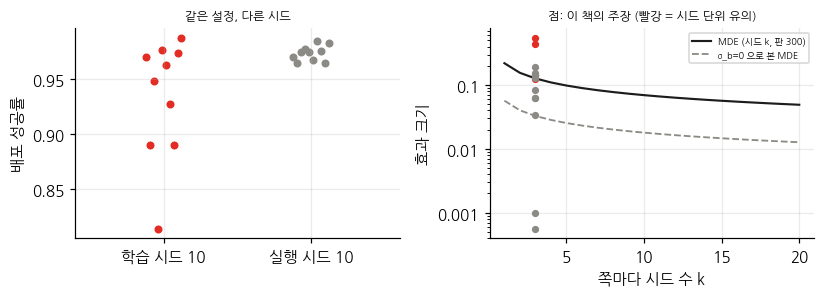

In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.6, 2.8))
for x, (kn, col, lab) in enumerate(((TR, RED, "학습 시드"),
                                    (EX, GREY, "실행 시드"))):
    r = [k / n for k, n in kn]
    xs = np.full(len(r), x) + np.linspace(-.12, .12, len(r))
    a1.scatter(xs, r, color=col, s=18)
a1.set_xticks([0, 1], ["학습 시드 10", "실행 시드 10"])
a1.set_ylabel("배포 성공률")
a1.set_xlim(-.6, 1.6)
a1.set_title("같은 설정, 다른 시드", fontsize=8)
ks = np.arange(1, 21)
a2.plot(ks, [mde(k, 300) for k in ks], color=INK, lw=1.4,
        label="MDE (시드 k, 판 300)")
a2.plot(ks, [mde(k, 300, 0.) for k in ks], color=GREY, ls="--",
        lw=1.2, label="σ_b=0 으로 본 MDE")
for a in AUD:
    if a["kind"] == "학습":
        a2.scatter(3, abs(a["delta"]), s=14,
                   color=RED if a["p_sd"] < .05 else GREY, zorder=3)
a2.set_xlabel("쪽마다 시드 수 k")
a2.set_ylabel("효과 크기")
a2.set_yscale("log")
a2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
a2.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: ""))
a2.legend(fontsize=6)
a2.set_title("점: 이 책의 주장 (빨강 = 시드 단위 유의)", fontsize=8)
plt.tight_layout()
plt.show()

## 산출물

In [15]:
out = {"claims": AUD,
       "seed_spread": {"train_sd": float(sd_tr),
                       "exec_sd": float(spread(EX)[1]),
                       "binom_sd": float(b_tr),
                       "sigma_b": float(np.sqrt(SB2)),
                       "p0": P0},
       "aa_false_alarm": {k: {"fisher": v[0], "bootstrap": v[1]}
                          for k, v in AA.items()},
       "mde_k3_m300": float(mde(3, 300))}
with open("report/audit.json", "w") as f:
    json.dump(out, f, ensure_ascii=False, indent=1)
save_log("report/ch16_log.csv", LOG)
print("report/audit.json 저장")
print(f"report/ch16_log.csv  판별 로그 {len(LOG):,}줄")

report/audit.json 저장
report/ch16_log.csv  판별 로그 7,806줄
